<a href="https://colab.research.google.com/github/khalidashani/MscProject/blob/main/Time_Series_Analysis_Airlines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 1: Exploratory Data Analysis (EDA)
Before building a predictive model, we must understand the underlying patterns of our time series. We use Seasonal Decomposition to strip away the noise and see the core components of the data.

1. Seasonal Decomposition Analysis
In the plots above, we broke the "Air Passengers" data into four distinct parts:

2. Observed: The raw data showing an overall increase in passengers over time.

3. Trend: A clear, upward linear trajectory. This indicates long-term growth in the airline industry during this period.

4. Seasonal: A highly repetitive pattern that peaks and troughs at the same time every year. This represents holiday travel cycles (e.g., summer vacations).

5. Residual (Resid): The "random noise" or outliers. Since the residuals are relatively stable, it suggests our decomposition model fits the data well.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Use a built-in Air Passengers dataset (classic for time series)
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')

# Phase 2: Statistical Stationarity Check
Most time series models (like ARIMA) require the data to be stationary (meaning its mean and variance don't change over time).

Note: Looking at our "Trend" plot, we can visually confirm the data is not stationary because the mean is increasing. To handle this, we will likely need to use "differencing" or a model like Prophet that handles non-stationary data automatically.

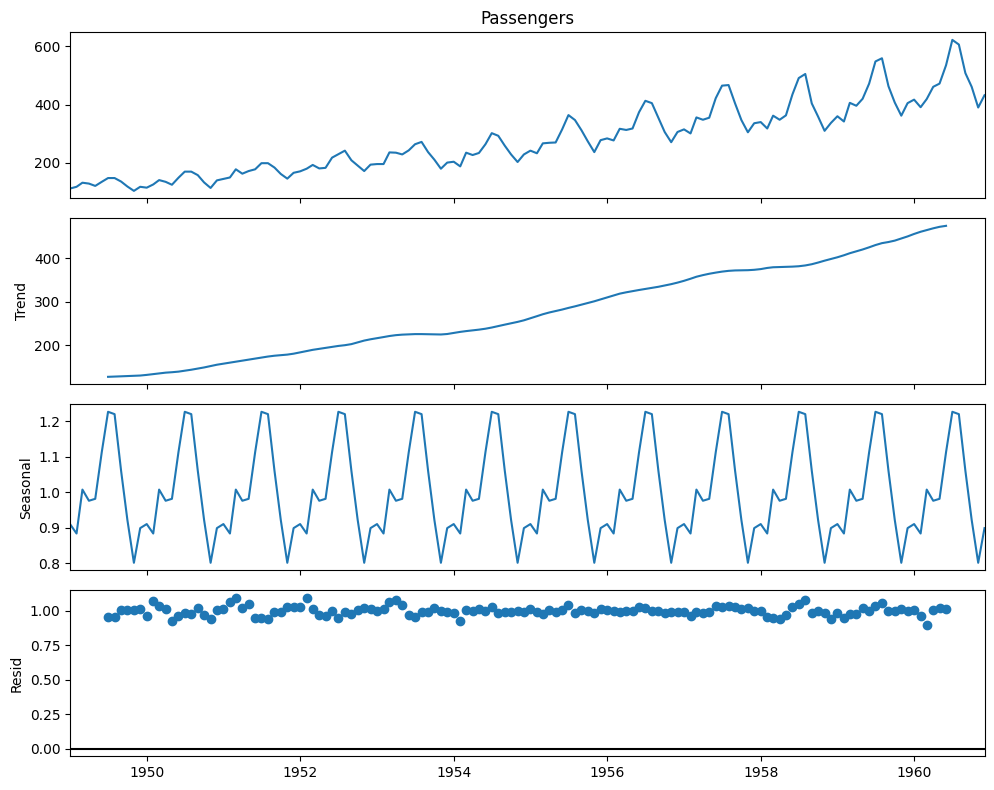

In [3]:
# We use 'multiplicative' because the variance increases over time
result = seasonal_decompose(df['Passengers'], model='multiplicative')

# Plotting with style
plt.rcParams.update({'figure.figsize': (10,8)})
result.plot()
plt.show()

# Phase 3: Forecasting
Now that we understand the history (Trend + Seasonality), our next goal is to predict the future. We will use the Prophet library because:

It is robust to missing data.

It handles dramatic seasonal shifts automatically.

It provides "uncertainty intervals" (the shaded area showing how confident the model is).

## Step 1: Prepare and Fit the Model

In [4]:
from prophet import Prophet

# 1. Prophet requires specific column names: 'ds' for dates and 'y' for values
df_prophet = df.reset_index().rename(columns={'Month': 'ds', 'Passengers': 'y'})

# 2. Initialize and fit the model
# We use multiplicative seasonality because the "swings" get larger over time
model = Prophet(seasonality_mode='multiplicative')
model.fit(df_prophet)

# 3. Create a "future" dataframe for the next 24 months
future = model.make_future_dataframe(periods=24, freq='MS')
forecast = model.predict(future)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


## Step 2: Visualize the Forecast

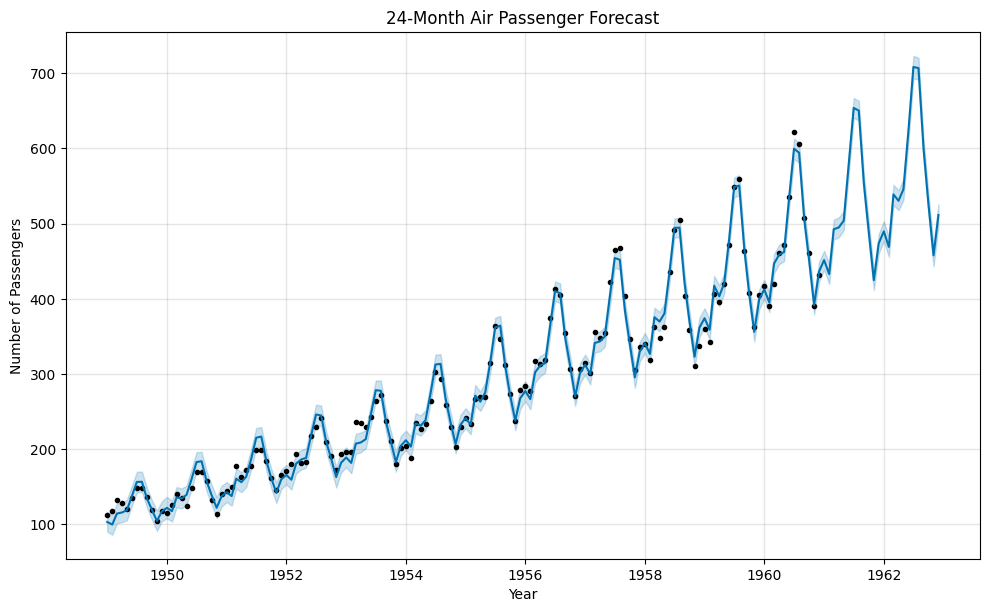

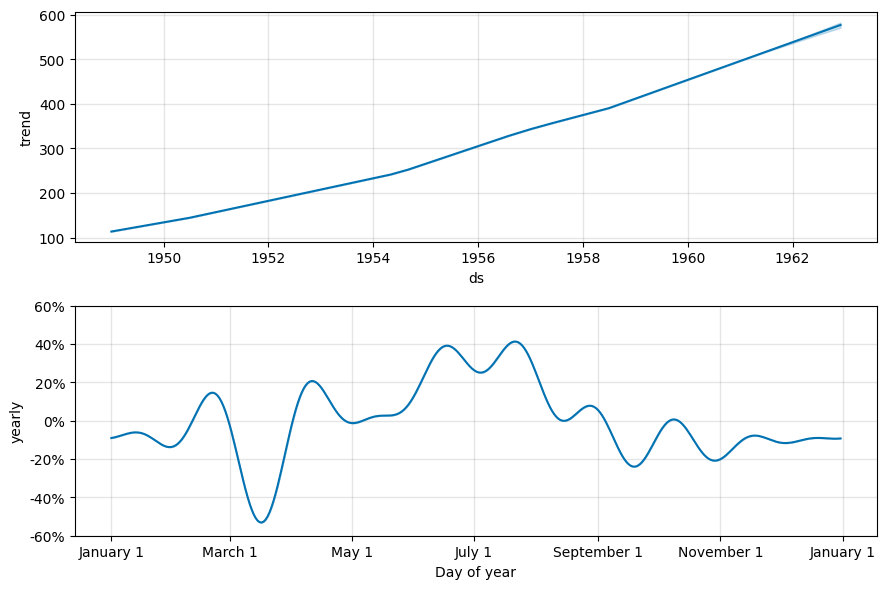

In [5]:
# Plot the main forecast
fig1 = model.plot(forecast)
plt.title("24-Month Air Passenger Forecast")
plt.xlabel("Year")
plt.ylabel("Number of Passengers")
plt.show()

# Plot the components (Trend, Weekly, Yearly)
fig2 = model.plot_components(forecast)
plt.show()

After decomposing the signal, we applied the Prophet forecasting model to predict passenger volume for the next two years.

**KEY OBSERVATION**
1. **Forecast Accuracy**: The black dots (actual data) sit closely within the light blue shaded region (uncertainty interval), suggesting the model captured the historical variance well.

2. **Component Breakdown**:

   * **Trend**: The model confirms a steady upward trajectory continuing into the future.

   * **Yearly Seasonality**: We see a massive peak in July/August and a secondary peak in December, confirming the model has "learned" summer and winter holiday trends.

3. **Projection**: Based on the model, we expect passenger volume to exceed 500 units within the next 12–18 months.